In [2]:
import myQMLlib as myQML
import numpy as np
import matplotlib.pyplot as plt
import time
import json
import os

#Code to automatically reload the myQMLfunctions module when it is edited
%load_ext autoreload
%autoreload 2

In [ ]:
####### Helper Function #########
def get_n_qubit_observable(n, base_op):
    """
    Generates an n-qubit observable by taking the tensor product 
    of the base_op n times. E.g., for base_op = X, returns X^otimes n.
    """
    obs = base_op
    for _ in range(n - 1):
        obs = np.kron(obs, base_op)
    return obs

####### Settings #########
# Put ONLY the qubit numbers you want to simulate right now.
n_qubits_list = [4] 

N_train = 40                
N_test = 100                 
num_realizations = 100
num_shots = 1000
reg_lambda = 0 
d_res = 32
filename = f"qubit_scaling_N{N_train}_shots{num_shots}.json"

# --- LOAD PREVIOUS DATA IF IT EXISTS ---
if os.path.exists(filename):
    print(f"Found existing file '{filename}'. Loading previous data...")
    with open(filename, 'r') as f:
        saved_data = json.load(f)
else:
    print("No previous data found. Starting fresh.")
    saved_data = {'QELM': {}, 'Kernel_LE': {}, 'Kernel_SWAP': {}}

# Filter n_qubits_list to ONLY calculate values we haven't done yet
n_to_run = [n for n in n_qubits_list if str(n) not in saved_data['QELM']]

if not n_to_run:
    print("All n values in the list have already been simulated. Exiting simulation phase.")
else:
    print(f"Simulating for n = {n_to_run}")
    print(f"-------- (Fixed N_train = {N_train}, Shots = {num_shots}, Realizations = {num_realizations}) --------")
    print("="*70)

    total_time = time.time()

    povm = myQML.generate_computational_povm(d_res)
    num_povm_elements = len(povm)

    for n in n_to_run:
        d_in = 2**n              
        d_out = d_in * d_res     
        
        print(f"Evaluating n = {n} qubits (d_in = {d_in})...")
        step_time = time.time()

        obs_n = get_n_qubit_observable(n, myQML.X)
        
        # Temporary lists for the current 'n'
        mse_qelm = []
        mse_le = []
        mse_swap = []

        for r in range(num_realizations):
            ds = myQML.QuantumDatasetGenerator(N_train, N_test, obs_n)
            ds.generate_density_matrices_vec()
            ds.compute_expectation_values_vec()
            
            rho_train, y_train = ds.get_training_dataset()
            rho_test, y_test = ds.get_test_dataset()

            # QELM
            V = myQML.random_isometry(d_in, d_out)
            qelm = myQML.QuantumExtremeLearningMachine(
                isometry=V, povm=povm, bipartite_dims=(d_in, d_res), 
                keep_subsystem=1, num_shots=num_shots
            )
            qelm.fit_vec(rho_train, y_train)
            # Use float() to ensure it is JSON serializable
            mse_qelm.append(float(np.mean((qelm.predict_vec(rho_test) - y_test)**2)))
            
            # Kernel LE
            kernel_le = myQML.QuantumKernelRegression(reg_lambda, num_shots)
            kernel_le.fit_vec(rho_train, y_train, "le")
            mse_le.append(float(np.mean((kernel_le.predict_vec(rho_test) - y_test)**2)))

            # Kernel SWAP
            kernel_swap = myQML.QuantumKernelRegression(reg_lambda, num_shots)
            kernel_swap.fit_vec(rho_train, y_train, "swap")
            mse_swap.append(float(np.mean((kernel_swap.predict_vec(rho_test) - y_test)**2)))

        # Update dictionary (JSON needs strings as keys)
        saved_data['QELM'][str(n)] = mse_qelm
        saved_data['Kernel_LE'][str(n)] = mse_le
        saved_data['Kernel_SWAP'][str(n)] = mse_swap

        # Save incrementally after every 'n' finishes
        with open(filename, 'w') as f:
            json.dump(saved_data, f, indent=4)

        print(f"  -> QELM Mean MSE: {np.mean(mse_qelm):.4f}")
        print(f"  -> K-LE Mean MSE: {np.mean(mse_le):.4f}")
        print(f"  -> K-SW Mean MSE: {np.mean(mse_swap):.4f}")
        print(f"  -> Time taken:    {time.time() - step_time:.1f}s")

    print("="*70)
    print(f"Simulation finished and saved to '{filename}' in {(time.time() - total_time)/60:.1f} minutes.")

Found existing file 'qubit_scaling_N40_shots1000.json'. Loading previous data...
Simulating for n = [3, 4]
-------- (Fixed N_train = 40, Shots = 1000, Realizations = 100) --------
Evaluating n = 3 qubits (d_in = 8)...
  -> QELM Mean MSE: 0.0700
  -> K-LE Mean MSE: 9.3623
  -> K-SW Mean MSE: 11.7163
  -> Time taken:    8216.9s
Evaluating n = 4 qubits (d_in = 16)...


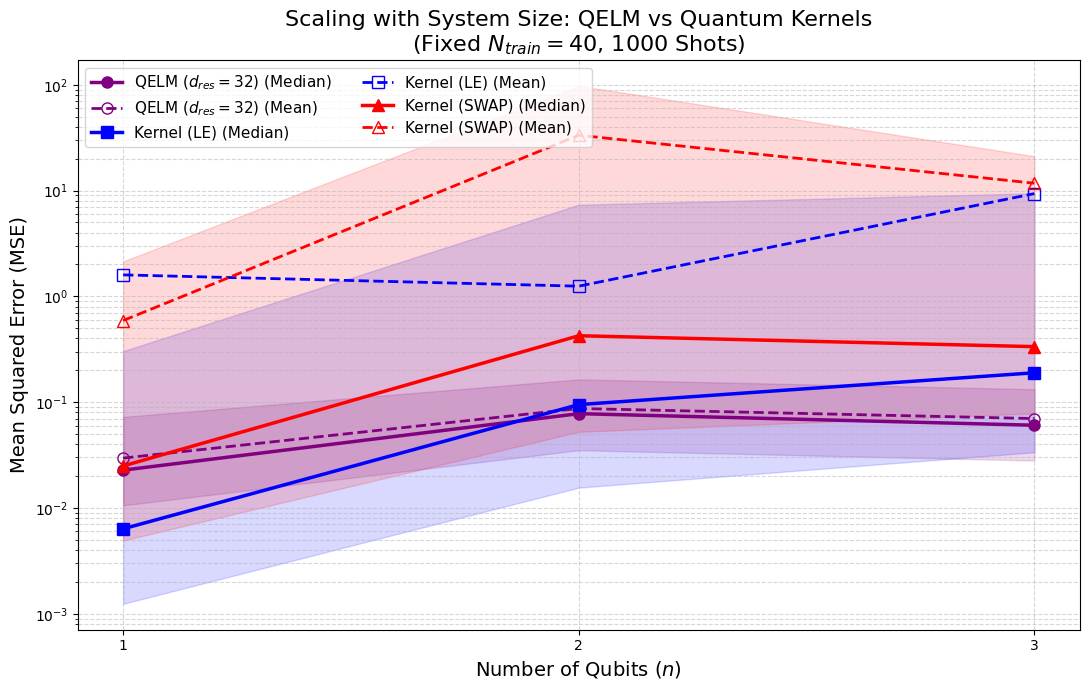

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

N_train = 40      
num_shots = 1000  
d_res = 32        

filename = f"qubit_scaling_N{N_train}_shots{num_shots}.json"

# 1. Load the data
with open(filename, 'r') as f:
    data = json.load(f)

# Extract n values present in the file and sort them numerically
n_qubits_list = sorted([int(k) for k in data['QELM'].keys()])
n_arr = np.array(n_qubits_list)

# Storage dictionaries for final plotting
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

# 2. Compute statistics
for n in n_qubits_list:
    str_n = str(n) # JSON keys are strings
    for model in ['QELM', 'Kernel_LE', 'Kernel_SWAP']:
        mse_array = np.array(data[model][str_n])
        
        results_mean[model].append(np.mean(mse_array))
        results_median[model].append(np.median(mse_array))
        quantiles_5[model].append(np.percentile(mse_array, 5))
        quantiles_95[model].append(np.percentile(mse_array, 95))

# ==========================================
# 3. Plotting Setup
# ==========================================
plt.figure(figsize=(11, 7))

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': f'QELM ($d_{{res}}={d_res}$)', 
          'Kernel_LE': 'Kernel (LE)', 
          'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # Plot Median (Solid)
    plt.plot(n_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # Plot Mean (Dashed, Empty marker)
    plt.plot(n_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8, fillstyle='none')
    
    # Fill between 5% and 95% quantiles
    plt.fill_between(n_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15)

plt.xticks(n_qubits_list) 
plt.yscale('log') 

plt.xlabel('Number of Qubits ($n$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'Scaling with System Size: QELM vs Quantum Kernels\n(Fixed $N_{{train}} = {N_train}$, {num_shots} Shots)', fontsize=16)

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11, ncol=2, loc='upper left')
plt.tight_layout()
plt.show()